Found 16 files
所有 50 个 test points 都已经有 coverage。


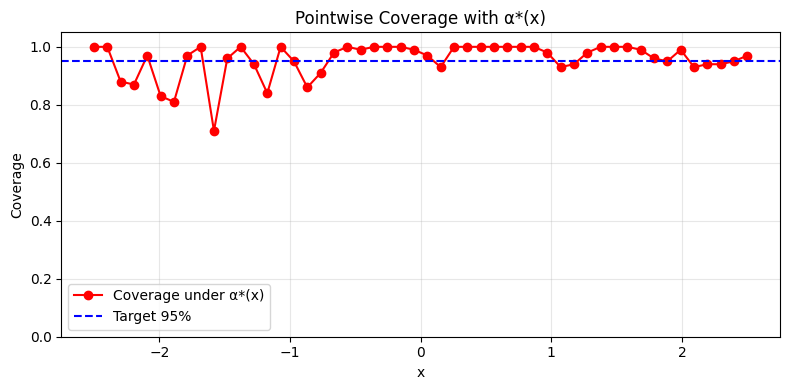

Merged CSV saved to: C:\Users\yangy\重现\results\alpha_star_pointwise_coverage_merged.csv


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 结果目录（注意用 r'' 原始字符串，Windows 路径里的反斜杠不会被转义）
base_dir = r"C:\Users\yangy\重现\results"

# 2. 找到所有 per-alpha 的 csv
pattern = os.path.join(base_dir, "alpha_star_pointwise_coverage_alphaidx*.csv")
csv_files = sorted(glob.glob(pattern))
print(f"Found {len(csv_files)} files")

if not csv_files:
    raise RuntimeError("没有找到任何 alpha_star_pointwise_coverage_alphaidx*.csv 文件，请检查路径或文件名。")

# 3. 先用第一份文件拿到 x / alpha_star 的骨架
base_df = pd.read_csv(csv_files[0])
x = base_df["x"].values
alpha_star = base_df["alpha_star"].values

# 初始化 coverage 为 NaN，后面用各个文件的非空值填充
coverage = np.full_like(x, np.nan, dtype=float)

# 4. 逐个文件合并 coverage_alpha_star
for f in csv_files:
    df = pd.read_csv(f)

    # sanity check: x 和 alpha_star 顺序应该完全一致
    assert np.allclose(df["x"].values, x)
    assert np.allclose(df["alpha_star"].values, alpha_star)

    mask = df["coverage_alpha_star"].notna()
    coverage[mask.to_numpy()] = df.loc[mask, "coverage_alpha_star"].values

# 检查是否还有没被填到的点
if np.isnan(coverage).any():
    idx_bad = np.where(np.isnan(coverage))[0]
    print("Warning: 还有这些位置没有 coverage 被填到：", idx_bad)
else:
    print("所有 50 个 test points 都已经有 coverage。")

# 5. 画图：红色为 coverage，蓝色为 0.95 target 线
plt.figure(figsize=(8, 4))
plt.plot(x, coverage, "r-o", label="Coverage under α*(x)")
plt.axhline(0.95, color="blue", linestyle="--", label="Target 95%")

plt.xlabel("x")
plt.ylabel("Coverage")
plt.ylim(0.0, 1.05)
plt.title("Pointwise Coverage with α*(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# （可选）顺手把合并后的结果存成一个总 csv
combined_df = pd.DataFrame({
    "x": x,
    "alpha_star": alpha_star,
    "coverage_alpha_star": coverage,
})
combined_path = os.path.join(base_dir, "alpha_star_pointwise_coverage_merged.csv")
combined_df.to_csv(combined_path, index=False)
print("Merged CSV saved to:", combined_path)


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\yangy\重现\results\alpha_star_pointwise_coverage_merged.csv")
print(df["coverage_alpha_star"].describe())

min_idx = df["coverage_alpha_star"].idxmin()
print("worst point:\n", df.iloc[min_idx])


count    50.000000
mean      0.956200
std       0.061075
min       0.710000
25%       0.940000
50%       0.980000
75%       1.000000
max       1.000000
Name: coverage_alpha_star, dtype: float64
worst point:
 x                     -1.581633
alpha_star             1.000000
coverage_alpha_star    0.710000
Name: 9, dtype: float64


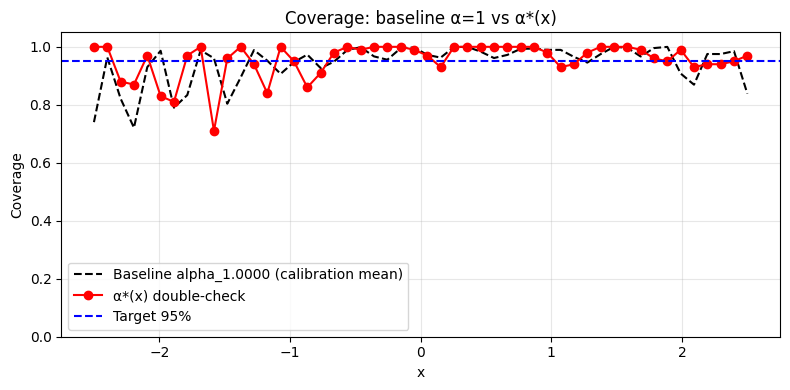

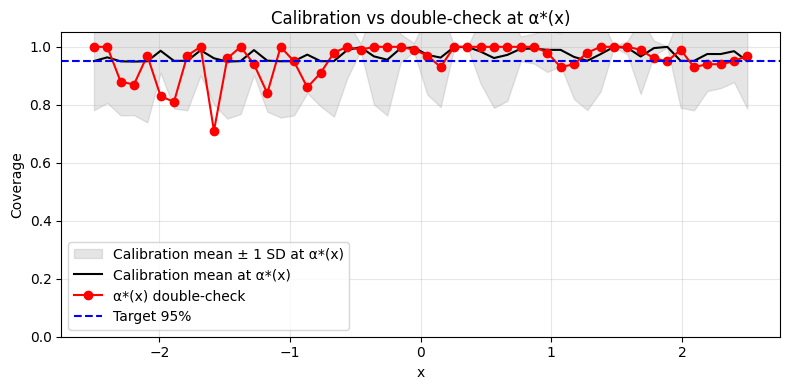

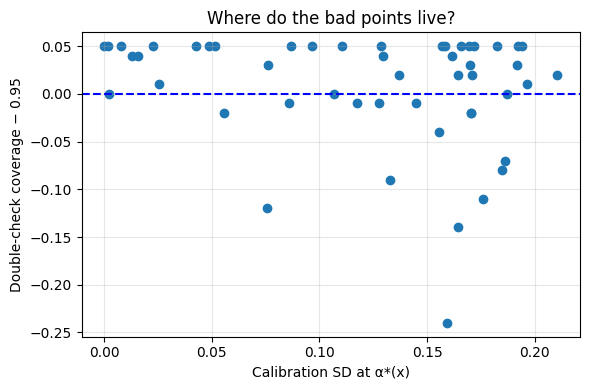

Most under-covered points (double-check):
          x  alpha_star  cov_doublecheck  calib_mean  calib_sd
0 -1.581633        1.00             0.71     0.96055  0.159108
1 -1.887755        0.41             0.81     0.95160  0.164557
2 -1.989796        1.00             0.83     0.98635  0.075696
3 -1.173469        1.00             0.84     0.95225  0.175978
4 -0.867347        1.00             0.86     0.97310  0.132570


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- 路径 ----------------
base_dir = r"C:\Users\yangy\重现\results"

# calibration mean / std （都是 csv）
mean_path = os.path.join(base_dir, "combined_pointwise_coverage_mean_over_reps.csv")
std_path  = os.path.join(base_dir, "combined_pointwise_coverage_std_over_reps.csv")

df_mean = pd.read_csv(mean_path)
df_std  = pd.read_csv(std_path)

# double-check 合并结果
dc_path = os.path.join(base_dir, "alpha_star_pointwise_coverage_merged.csv")
df_dc   = pd.read_csv(dc_path)

# ---------------- 对齐 x / 取出 alpha* ----------------
x_dc = df_dc["x"].values
alpha_star = df_dc["alpha_star"].values
cov_dc = df_dc["coverage_alpha_star"].values

# sanity check：x 轴应该一样
if not np.allclose(x_dc, df_mean["x"].values):
    print("Warning: x from double-check and calibration do not match perfectly.")

# ---------------- 1. baseline α=1 vs α*(x) double-check ----------------
# 找到代表 α=1 的列（列名大概像 alpha_1.0000）
alpha1_candidates = [c for c in df_mean.columns if c.startswith("alpha_1.")]
if not alpha1_candidates:
    raise KeyError("找不到 alpha=1 的列名（形如 alpha_1.0000），请检查 combined_pointwise_coverage_mean_over_reps.csv.")
alpha1_col = alpha1_candidates[0]

cov_alpha1_mean = df_mean[alpha1_col].values

plt.figure(figsize=(8, 4))
plt.plot(df_mean["x"].values, cov_alpha1_mean, "k--", label=f"Baseline {alpha1_col} (calibration mean)")
plt.plot(x_dc, cov_dc, "r-o", label="α*(x) double-check")
plt.axhline(0.95, color="blue", linestyle="--", label="Target 95%")
plt.xlabel("x"); plt.ylabel("Coverage")
plt.ylim(0.0, 1.05)
plt.title("Coverage: baseline α=1 vs α*(x)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------- 2. 在 α*(x) 上取 calibration mean & sd ----------------
calib_mean_star = np.empty_like(alpha_star, dtype=float)
calib_std_star  = np.empty_like(alpha_star, dtype=float)

for j, (xj, a_j) in enumerate(zip(x_dc, alpha_star)):
    col = f"alpha_{a_j:.4f}"  # e.g. alpha_0.4300
    if col not in df_mean.columns:
        raise KeyError(f"Column {col} not found in mean/std tables.")
    row_mask = np.isclose(df_mean["x"].values, xj)
    if not row_mask.any():
        raise ValueError(f"x={xj} not found in calibration tables.")
    calib_mean_star[j] = df_mean.loc[row_mask, col].values[0]
    calib_std_star[j]  = df_std.loc[row_mask,  col].values[0]

# 图 2：calibration mean ±1 SD + double-check
plt.figure(figsize=(8, 4))
upper = calib_mean_star + calib_std_star
lower = calib_mean_star - calib_std_star
plt.fill_between(x_dc, lower, upper, color="grey", alpha=0.2,
                 label="Calibration mean ± 1 SD at α*(x)")

plt.plot(x_dc, calib_mean_star, "k-", label="Calibration mean at α*(x)")
plt.plot(x_dc, cov_dc, "r-o", label="α*(x) double-check")
plt.axhline(0.95, color="blue", linestyle="--", label="Target 95%")

plt.xlabel("x"); plt.ylabel("Coverage")
plt.ylim(0.0, 1.05)
plt.title("Calibration vs double-check at α*(x)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------- 3. SD vs 距 0.95 的偏差 ----------------
diff_from_95 = cov_dc - 0.95    # 正：overcover，负：undercover

plt.figure(figsize=(6, 4))
plt.scatter(calib_std_star, diff_from_95)
plt.axhline(0.0, color="blue", linestyle="--")
plt.xlabel("Calibration SD at α*(x)")
plt.ylabel("Double-check coverage − 0.95")
plt.title("Where do the bad points live?")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# （可选）打印几个最差的点方便你对照 x / α*(x)
worst_idx = np.argsort(diff_from_95)[:5]  # 最 under 的 5 个点
print("Most under-covered points (double-check):")
print(pd.DataFrame({
    "x": x_dc[worst_idx],
    "alpha_star": alpha_star[worst_idx],
    "cov_doublecheck": cov_dc[worst_idx],
    "calib_mean": calib_mean_star[worst_idx],
    "calib_sd": calib_std_star[worst_idx],
}))
